<a href="https://colab.research.google.com/github/kaushalkalas-awesome/DKTE-TY-DL/blob/main/DL_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [60]:
data = load_breast_cancer()
X, y = data.data, data.target

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Dataset         : Breast Cancer Wisconsin")
print(f"Classes         : {data.target_names}")   # Malignant / Benign
print(f"Train samples   : {X_train.shape[0]}")
print(f"Test samples    : {X_test.shape[0]}")
print(f"Features        : {X_train.shape[1]}")

Dataset         : Breast Cancer Wisconsin
Classes         : ['malignant' 'benign']
Train samples   : 455
Test samples    : 114
Features        : 30


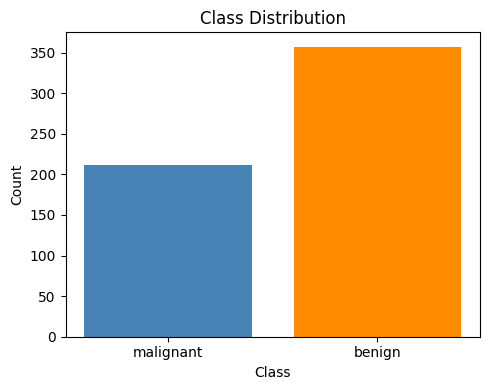

In [61]:
unique, counts = np.unique(y, return_counts=True)
plt.figure(figsize=(5, 4))
plt.bar(data.target_names, counts, color=['steelblue', 'darkorange'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [62]:
model_fixed = tf.keras.Sequential([
  tf.keras.layers.Dense(64, activation='relu', input_shape=(30,)),
  tf.keras.layers.Dense(32, activation='relu'),
  tf.keras.layers.Dense(1,  activation='sigmoid')
])

model_fixed.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
model_fixed.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [64]:
print("\nTraining with Fixed LR...")
history_fixed = model_fixed.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)


Training with Fixed LR...
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 593ms/step - accuracy: 0.4753 - loss: 0.7019 - val_accuracy: 0.6044 - val_loss: 0.6188
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7473 - loss: 0.5758 - val_accuracy: 0.8571 - val_loss: 0.5126
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8736 - loss: 0.4798 - val_accuracy: 0.8901 - val_loss: 0.4336
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9038 - loss: 0.4055 - val_accuracy: 0.9231 - val_loss: 0.3747
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9121 - loss: 0.3482 - val_accuracy: 0.9231 - val_loss: 0.3296
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9286 - loss: 0.3026 - val_accuracy: 0.9341 - val_loss: 0.2936
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9396 - loss: 0.2662 - val_accuracy: 0.9341 - val_loss: 0.2645
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9423 - loss: 0.2365 - val_accuracy

In [65]:
model_adaptive = tf.keras.Sequential([
  tf.keras.layers.Dense(64, activation='relu', input_shape=(30,)),
  tf.keras.layers.Dense(32, activation='relu'),
  tf.keras.layers.Dense(1,  activation='sigmoid')
])

model_adaptive.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
# Exponential Decay Schedule
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=500,
    decay_rate=0.9
)

# Early Stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [67]:
model_adaptive.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [68]:
print("\nTraining with Adaptive LR + Early Stopping...")
history_adaptive = model_adaptive.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Training with Adaptive LR + Early Stopping...
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 506ms/step - accuracy: 0.7170 - loss: 0.5047 - val_accuracy: 0.9341 - val_loss: 0.1984
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9423 - loss: 0.1642 - val_accuracy: 0.9560 - val_loss: 0.1183
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9643 - loss: 0.0919 - val_accuracy: 0.9670 - val_loss: 0.0916
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9753 - loss: 0.0666 - val_accuracy: 0.9560 - val_loss: 0.0902
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9808 - loss: 0.0621 - val_accuracy: 0.9560 - val_loss: 0.0901
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9808 - loss: 0.0526 - val_accuracy: 0.9560 - val_loss: 0.0901
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9835 - loss: 0.0428 - val_accuracy: 0.9670 - val_loss: 0.0941
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9918 - loss: 0

In [69]:
loss_f, acc_f = model_fixed.evaluate(X_test, y_test, verbose=0)
loss_a, acc_a = model_adaptive.evaluate(X_test, y_test, verbose=0)

In [70]:
epochs_fixed    = len(history_fixed.history['loss'])
epochs_adaptive = len(history_adaptive.history['loss'])

print(f"\nFixed LR    → Loss: {loss_f:.4f} | Accuracy: {acc_f*100:.2f}% | Epochs: {epochs_fixed}")
print(f"Adaptive LR → Loss: {loss_a:.4f} | Accuracy: {acc_a*100:.2f}% | Epochs: {epochs_adaptive}")


Fixed LR    → Loss: 0.1661 | Accuracy: 97.37% | Epochs: 10
Adaptive LR → Loss: 0.0697 | Accuracy: 98.25% | Epochs: 10


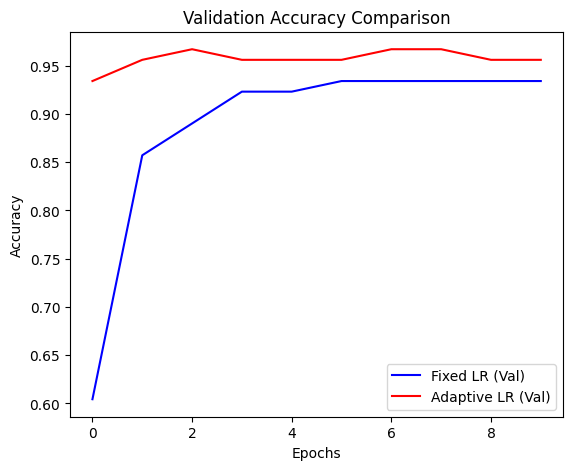

In [71]:
plt.figure(figsize=(14, 5))

# Validation Accuracy Comparison
plt.subplot(1, 2, 2)
plt.plot(history_fixed.history['val_accuracy'], label='Fixed LR (Val)', color='blue')
plt.plot(history_adaptive.history['val_accuracy'], label='Adaptive LR (Val)', color='red')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

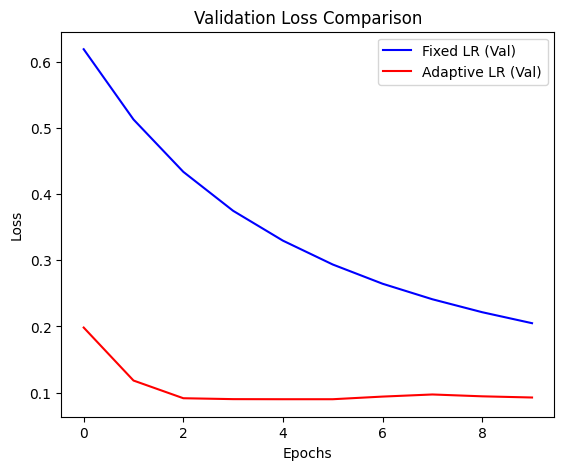

In [72]:
plt.figure(figsize=(14, 5))

# Validation Loss Comparison
plt.subplot(1, 2, 1)
plt.plot(history_fixed.history['val_loss'], label='Fixed LR (Val)', color='blue')
plt.plot(history_adaptive.history['val_loss'], label='Adaptive LR (Val)', color='red')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

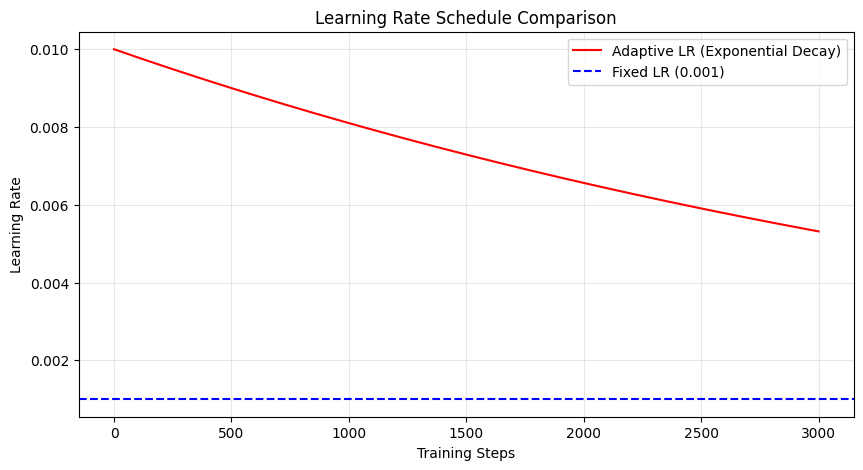

In [73]:
import numpy as np

# Calculate LR values for the adaptive schedule over the total steps
total_steps = 3000
steps = np.arange(total_steps)
lr_values = [lr_schedule(step).numpy() for step in steps]

plt.figure(figsize=(10, 5))
plt.plot(steps, lr_values, label='Adaptive LR (Exponential Decay)', color='red')
plt.axhline(y=0.001, color='blue', linestyle='--', label='Fixed LR (0.001)')

plt.title('Learning Rate Schedule Comparison')
plt.xlabel('Training Steps')
plt.ylabel('Learning Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()